In [6]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from scipy.signal import butter, filtfilt,sosfiltfilt
import matplotlib.pyplot as plt 

In [7]:
non_mace_dir = r'D:\M143020071\raw_data_result\conversion_data\healthy/'
mace_dir = r'D:\M143020071\raw_data_result\conversion_data\patient/'
save_non_mace_dir = r'D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\non_mace_zscore/'
save_mace_dir = r'D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\mace_zscore/'


In [8]:
for save_path in [save_non_mace_dir, save_mace_dir]:
    if not os.path.exists(save_path):
        os.makedirs(save_path)
        print(f'Created directory: {save_path}')
    else:
        print(f'Directory already exists: {save_path}')

Directory already exists: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\non_mace_zscore/
Directory already exists: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\mace_zscore/


In [9]:
def butter_bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos

def butter_lowpass_sos(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    sos = butter(order, normal_cutoff, btype='low', output='sos')
    return sos

fs = 10000 
five_min_pts = 5 * fs * 60
ten_min_pts = 10 * fs * 60

Processing :   0%|          | 0/434 [00:00<?, ?it/s]

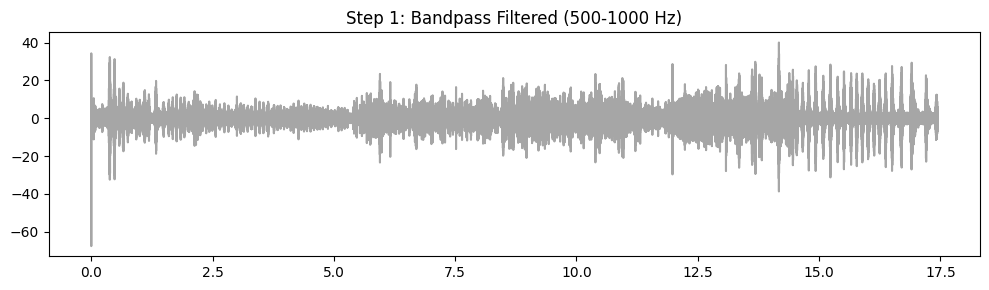

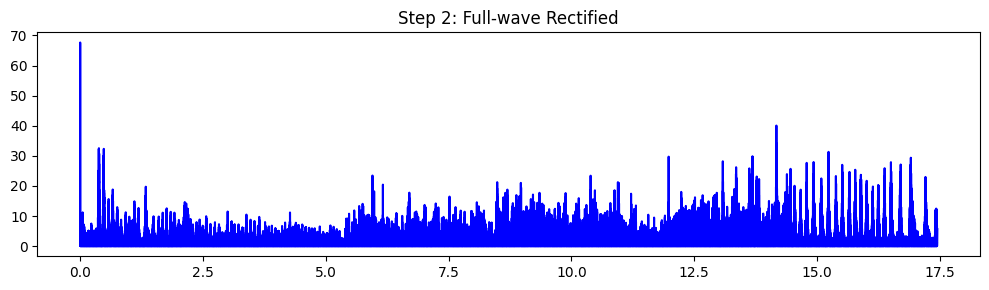

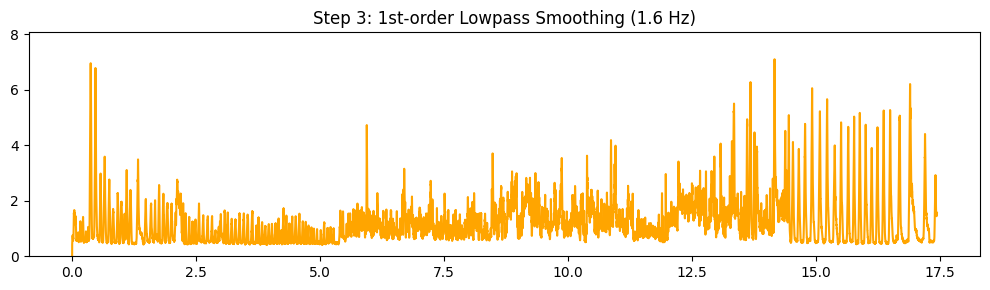

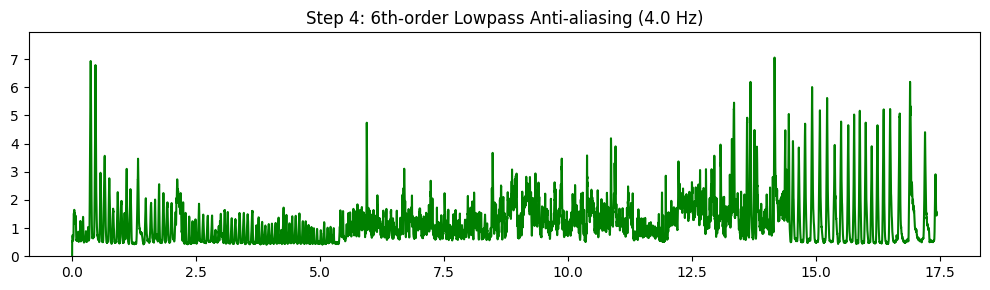

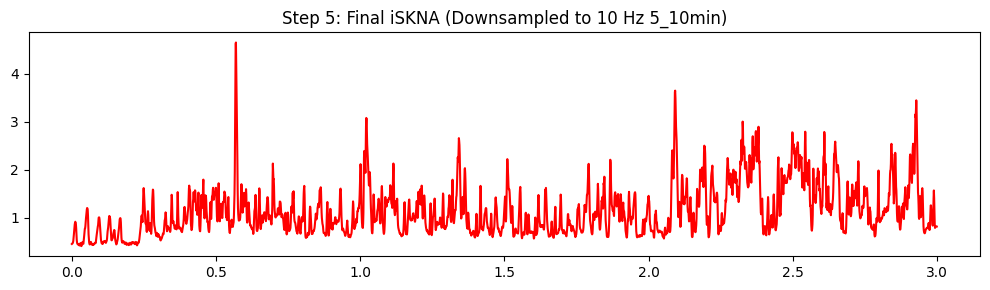

Processing :   0%|          | 0/434 [00:07<?, ?it/s]


Finished processing category and saved to: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\non_mace_zscore/


Processing :   0%|          | 0/92 [00:00<?, ?it/s]

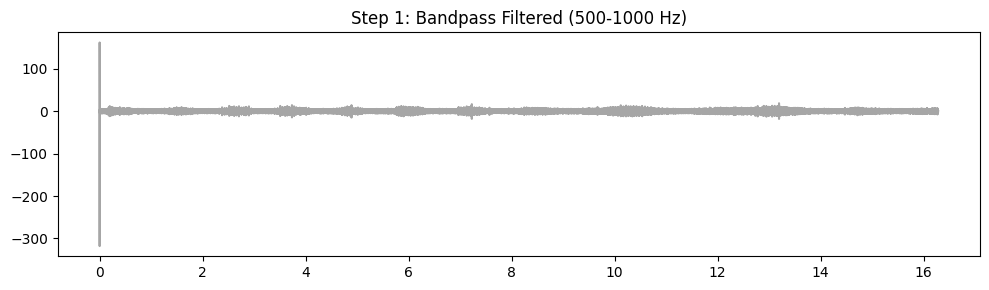

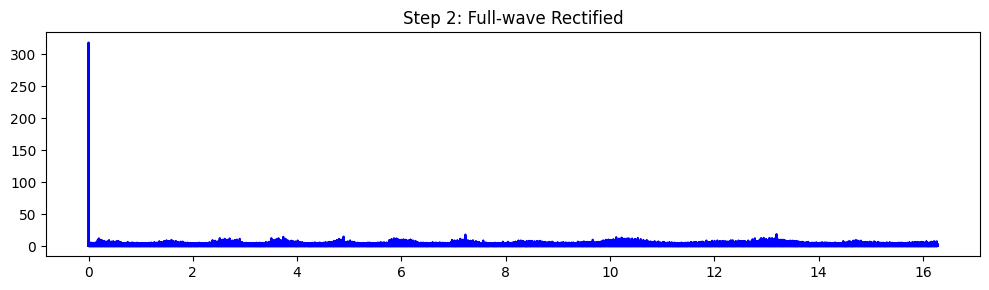

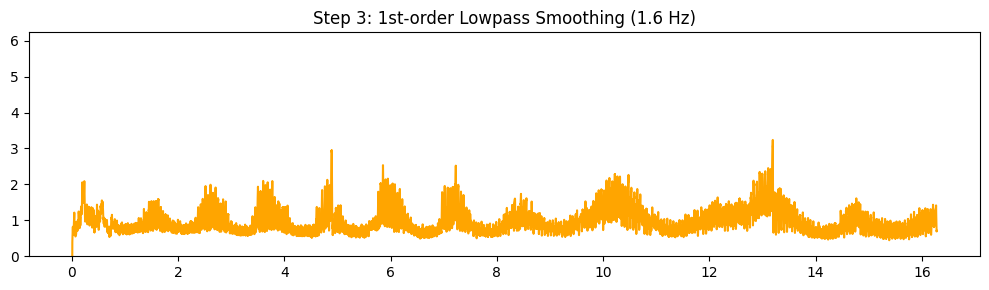

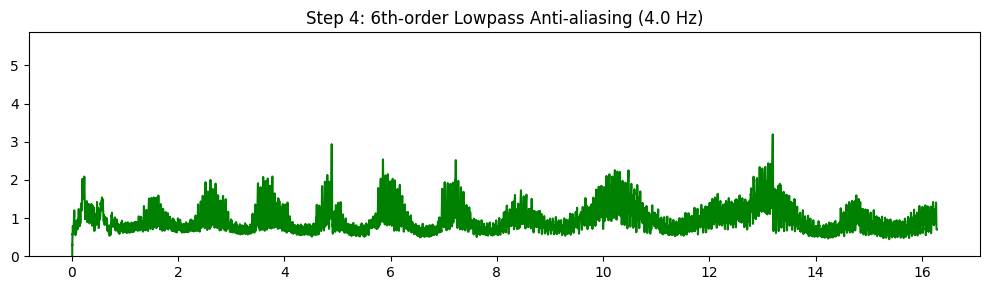

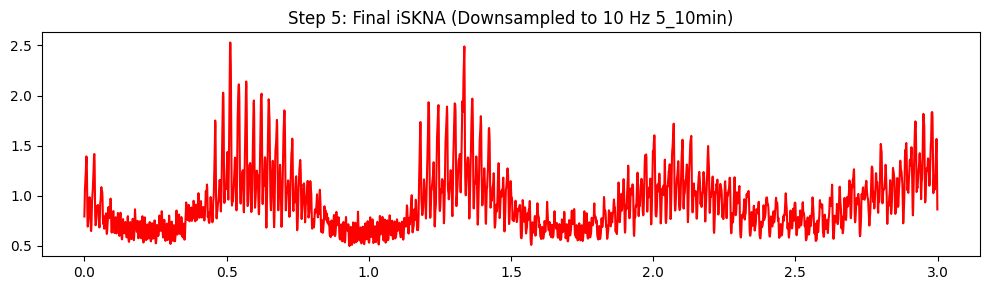

Processing :   0%|          | 0/92 [00:07<?, ?it/s]

Finished processing category and saved to: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_15s_ECG_signal_1000pts\mace_zscore/


In [ ]:
# 確保 visualized 旗標在切換資料夾時會重置
for data_dir, save_dir, label in zip([non_mace_dir, mace_dir], [save_non_mace_dir, save_mace_dir], [0, 1]):
    visualized = False  # 每個類別（健康/病患）各顯示一次圖表
    
    for filename in tqdm(os.listdir(data_dir), desc=f'Processing {os.path.basename(data_dir)}'):
        if filename.endswith('.csv'):
            try:
                # 1. 讀取資料
                df = pd.read_csv(os.path.join(data_dir, filename))
                # 假設欄位名稱為 'Ch1'，請確保與您的 csv 欄位一致
                signal = df['Ch1'].values

                # 2. 訊號處理流程
                # 帶通濾波
                sos_bp = butter_bandpass_sos(500, 1000, fs, order=2)
                filtered_sig = sosfiltfilt(sos_bp, signal)

                # 絕對值 (Rectification)
                rectified_sig = np.abs(filtered_sig)

                # 1階平滑 (1.6 Hz)
                sos_env = butter_lowpass_sos(1.6, fs, order=1)
                smoothed_env = sosfiltfilt(sos_env, rectified_sig)
                # 6階抗混疊 (4.0 Hz)
                sos_aa = butter_lowpass_sos(4.0, fs, order=6)
                anti_aliased_sig = sosfiltfilt(sos_aa, smoothed_env)
                current_sig_len = anti_aliased_sig.shape[0]
                
                if current_sig_len >= five_min_pts:
                    if current_sig_len < ten_min_pts:
                        # 情況 1: 長度在 5 到 10 分鐘之間 -> 抓取最後的 5 分鐘
                        start_offset = current_sig_len - five_min_pts
                        iskna_signal_segment = anti_aliased_sig[start_offset : ]
                        
                    else:
                        # 情況 2: 長度大於等於 10 分鐘 -> 抓取 5-10 分鐘這區間
                        start_offset = 5 * fs * 60
                        end_offset = 10 * fs * 60
                        iskna_signal_segment = anti_aliased_sig[start_offset : end_offset]
                        
                else:
                    
                    print(f"Error: 檔案 {filename} 太短 (僅 {current_sig_len/fs/60:.2f} 分鐘)，跳過處理。")
                    continue


                # 3. 降採樣 (10000Hz -> 10Hz)
                
                downsample = 1000
                iskna_signal_reshape = iskna_signal_segment.reshape(-1, 1000).mean(axis=1)
                
                iskna_signal = iskna_signal_reshape.reshape(-1)
                

                # 4. 視覺化檢查 (每個資料夾只執行一次)
                if not visualized:
                    time_axis = np.arange(len(signal)) / fs / 60
                    
                    plt.figure(figsize=(10, 3))
                    plt.plot(time_axis, filtered_sig, color='gray', alpha=0.7)
                    plt.title('Step 1: Bandpass Filtered (500-1000 Hz)')
                    plt.tight_layout()
                    plt.show()

                    plt.figure(figsize=(10, 3))
                    plt.plot(time_axis, rectified_sig, color='blue')
                    plt.title('Step 2: Full-wave Rectified')
                    plt.tight_layout()
                    plt.show()

                    plt.figure(figsize=(10, 3))
                    plt.plot(time_axis, smoothed_env, color='orange')
                    plt.title('Step 3: 1st-order Lowpass Smoothing (1.6 Hz)')
                    plt.ylim(bottom=0)
                    plt.tight_layout()
                    plt.show()

                    plt.figure(figsize=(10, 3))
                    plt.plot(time_axis, anti_aliased_sig, color='green')
                    plt.title('Step 4: 6th-order Lowpass Anti-aliasing (4.0 Hz)')
                    plt.ylim(bottom=0)
                    plt.tight_layout()
                    plt.show()
                    

                    time_axis_downsampled = np.arange(len(iskna_signal_reshape))/downsample
                    plt.figure(figsize=(10, 3))
                    plt.plot(time_axis_downsampled, iskna_signal_reshape, 'r-', markersize=3)
                    plt.title('Step 5: Final iSKNA (Downsampled to 10 Hz 5_10min)')
                    plt.tight_layout()
                    plt.show()
                    
                    visualized = True
                    
                    
                
                
                iskna_with_label = np.insert(iskna_signal, 0, label)
                
                
                base_name = os.path.splitext(filename)[0] # 取得不含副檔名的主檔名
                final_save_path = os.path.join(save_dir, f'{base_name}.npy')
                
                np.save(final_save_path, iskna_with_label)
                

            except Exception as e:
                print(f'Error processing file {filename}: {e}')
                
    print(f'Finished processing category and saved to: {save_dir}')